CORD-19 DATASET ANALYSIS PROJECT

📊 Loading CORD-19 metadata...
✅ Dataset loaded successfully!

📈 Dataset Shape: 1,056,660 rows × 19 columns

🔍 First 5 rows:
--------------------------------------------------------------------------------
                                               title  \
0  Clinical features of culture-proven Mycoplasma...   
1  Nitric oxide: a pro-inflammatory mediator in l...   
2    Surfactant protein-D and pulmonary host defense   
3               Role of endothelin-1 in lung disease   
4  Gene expression in epithelial cells in respons...   

                                             authors         journal  \
0                Madani, Tariq A; Al-Ghamdi, Aisha A  BMC Infect Dis   
1  Vliet, Albert van der; Eiserich, Jason P; Cros...      Respir Res   
2                                    Crouch, Erika C      Respir Res   
3  Fagan, Karen A; McMurtry, Ivan F; Rodman, David M      Respir Res   
4  Domachowske, Joseph B; Bonville, Cynthia A; Ro...      Respir

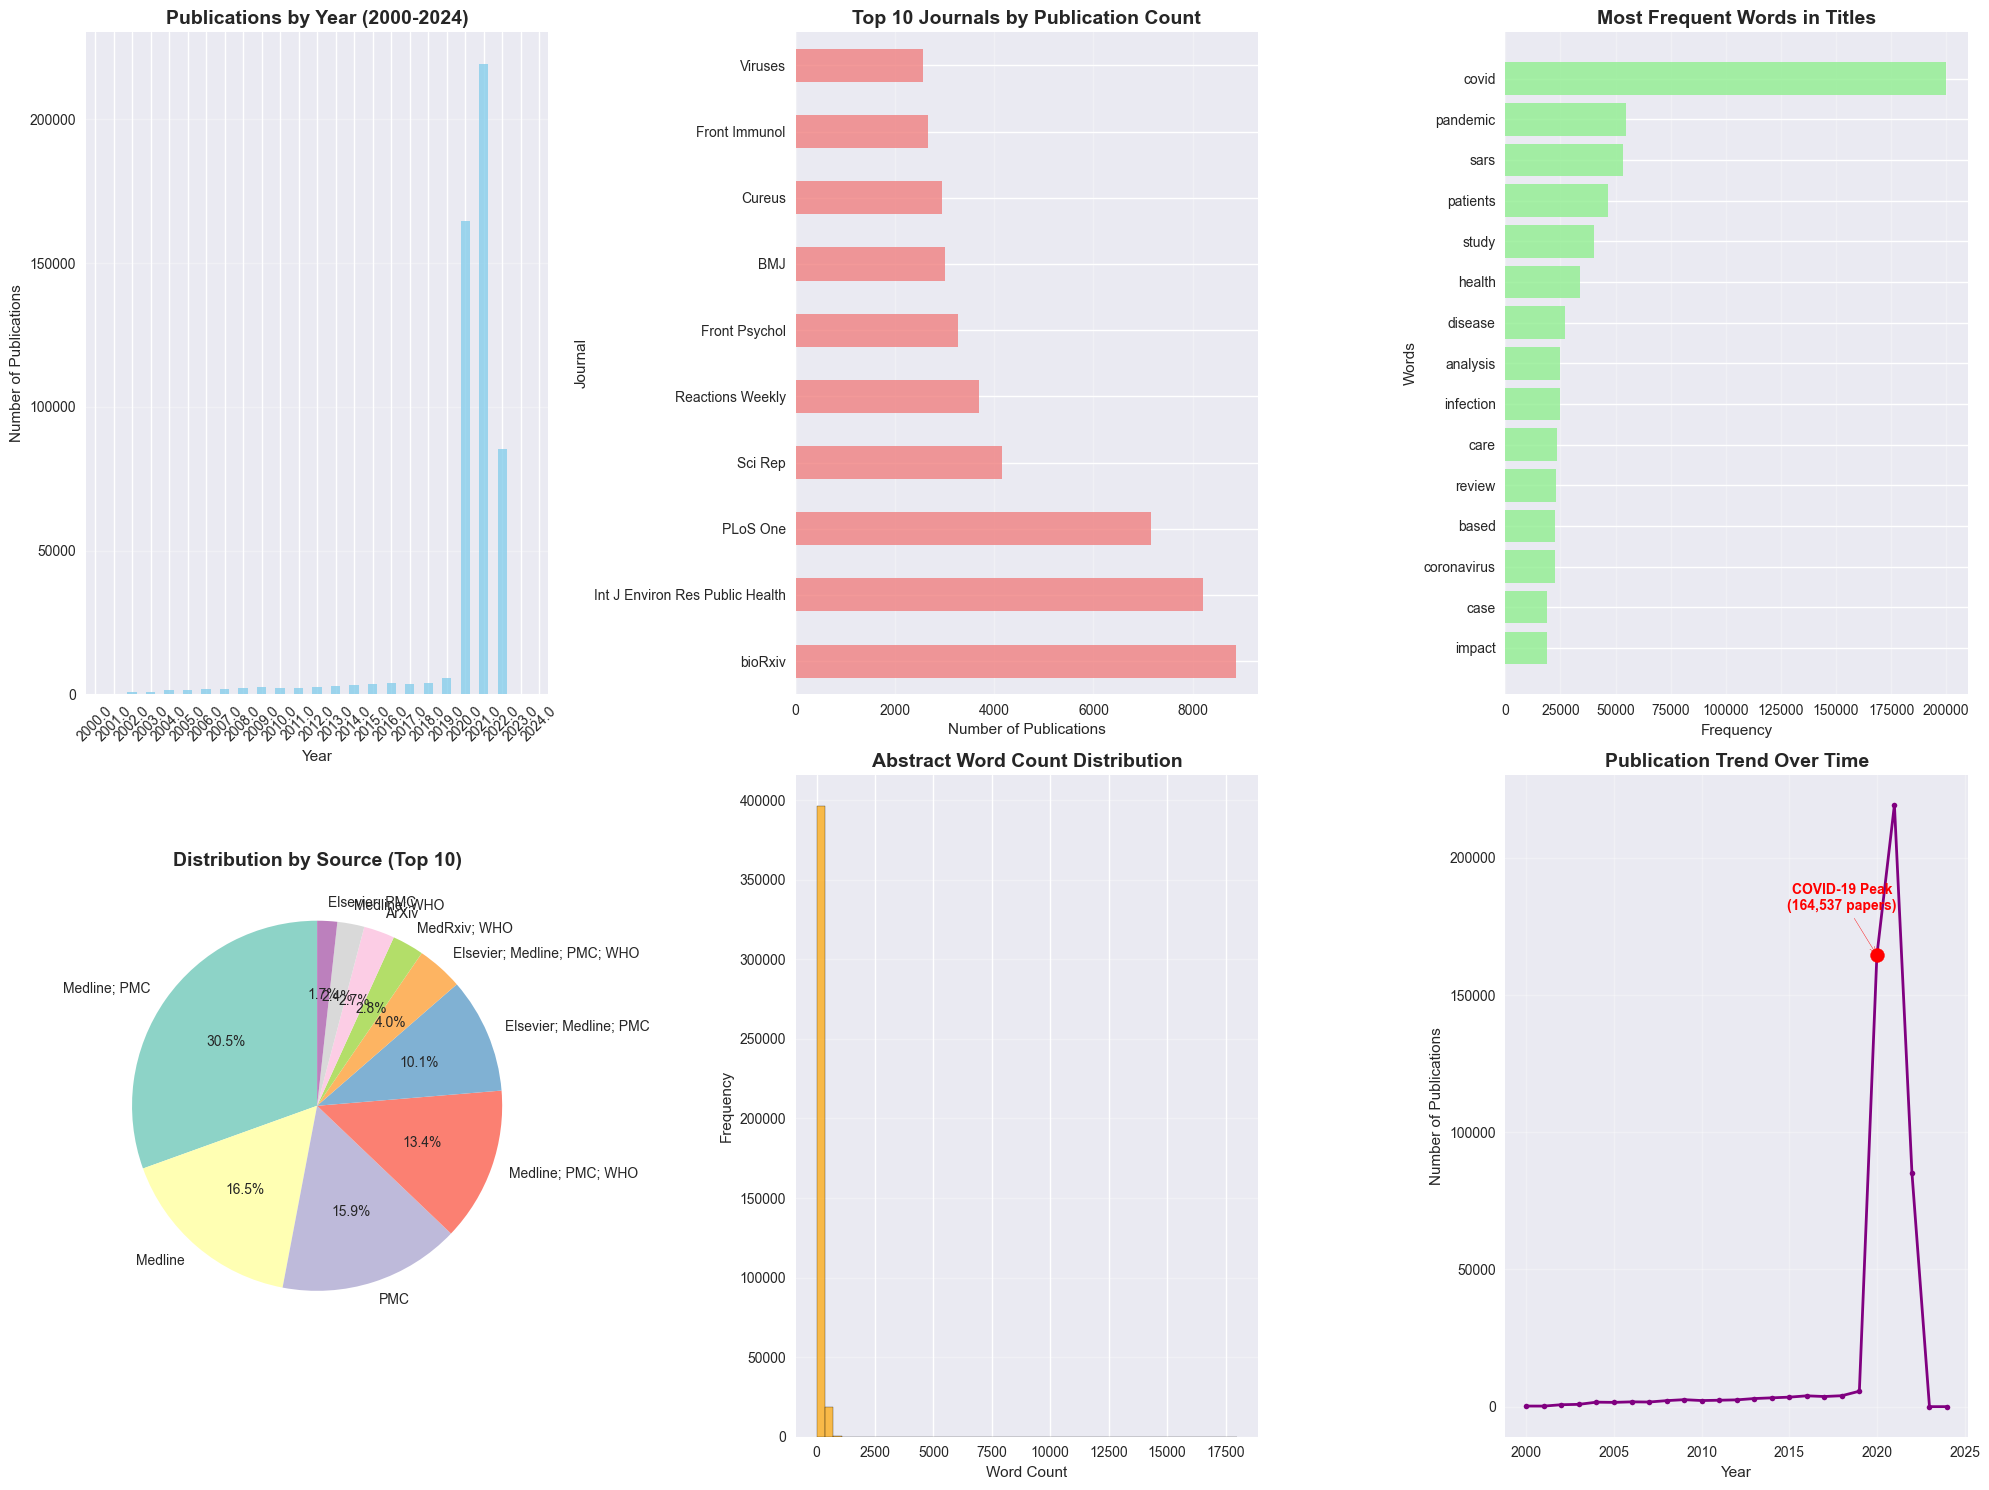


📋 Dataset Summary:
   • Total papers analyzed: 518,429
   • Number of columns: 22
   • Date range: 1856 - 2024
   • Average abstract length: 170.9 words
   • Number of unique journals: 20,380
   • Peak publication year: 2021.0 (219,335 papers)


In [1]:
# CORD-19 Dataset Analysis Project
# A comprehensive data science project analyzing COVID-19 research papers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


print("CORD-19 DATASET ANALYSIS PROJECT")


# PART 1: DATA LOADING & EXPLORATION

def load_and_explore_data(file_path='metadata.csv'):
    """
    Load the CORD-19 metadata.csv file and perform initial exploration.
    
    Args:
        file_path (str): Path to the metadata.csv file
        
    Returns:
        pandas.DataFrame: Loaded dataset
    """
    print("\n📊 Loading CORD-19 metadata...")
    
    try:
        # Load the dataset
        df = pd.read_csv(file_path)
        print(f"✅ Dataset loaded successfully!")
        
        # Basic information about the dataset
        print(f"\n📈 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
        
        # Display first few rows
        print("\n🔍 First 5 rows:")
        print("-" * 80)
        display_cols = ['title', 'authors', 'journal', 'publish_time']
        available_cols = [col for col in display_cols if col in df.columns]
        print(df[available_cols].head())
        
        # Data types
        print(f"\n🏷️  Data Types:")
        print("-" * 30)
        for col, dtype in df.dtypes.items():
            print(f"{col}: {dtype}")
        
        # Missing values analysis
        print(f"\n❌ Missing Values Analysis:")
        print("-" * 40)
        missing_data = df.isnull().sum()
        missing_percent = (missing_data / len(df)) * 100
        
        missing_info = pd.DataFrame({
            'Column': missing_data.index,
            'Missing Count': missing_data.values,
            'Missing %': missing_percent.values
        }).sort_values('Missing %', ascending=False)
        
        print(missing_info[missing_info['Missing Count'] > 0])
        
        # Basic statistics for numerical columns
        print(f"\n📊 Basic Statistics:")
        print("-" * 30)
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            print(df[numeric_cols].describe())
        else:
            print("No numerical columns found for statistics.")
        
        return df
        
    except FileNotFoundError:
        print(f"❌ Error: File '{file_path}' not found!")
        print("Please ensure the metadata.csv file is in the current directory.")
        return None
    except Exception as e:
        print(f"❌ Error loading data: {str(e)}")
        return None

# Load the data
df = load_and_explore_data()

if df is not None:

    # PART 2: DATA CLEANING & PREPARATION
    
    print("\n" + "="*20 + " PART 2: DATA CLEANING & PREPARATION " + "="*20)
    
    def clean_and_prepare_data(df):
        """
        Clean and prepare the dataset for analysis.
        
        Args:
            df (pandas.DataFrame): Raw dataset
            
        Returns:
            pandas.DataFrame: Cleaned dataset
        """
        print("\n🧹 Starting data cleaning process...")
        
        # Create a copy to avoid modifying original data
        df_clean = df.copy()
        
        # Handle missing values
        print("\n🔧 Handling missing values:")
        
        # Strategy for different columns:
        # 1. Keep rows with missing abstracts but note them
        # 2. Fill missing journals with 'Unknown'
        # 3. Fill missing authors with 'Unknown'
        # 4. Drop rows with missing titles (essential for analysis)
        
        initial_rows = len(df_clean)
        
        # Drop rows with missing titles (essential column)
        if 'title' in df_clean.columns:
            df_clean = df_clean.dropna(subset=['title'])
            print(f"   - Dropped {initial_rows - len(df_clean)} rows with missing titles")
        
        # Fill missing values for categorical columns
        categorical_fills = {
            'journal': 'Unknown Journal',
            'authors': 'Unknown Authors',
            'source_x': 'Unknown Source'
        }
        
        for col, fill_value in categorical_fills.items():
            if col in df_clean.columns:
                missing_before = df_clean[col].isnull().sum()
                df_clean[col] = df_clean[col].fillna(fill_value)
                print(f"   - Filled {missing_before} missing values in '{col}' with '{fill_value}'")
        
        # Convert publish_time to datetime and extract year
        print("\n📅 Processing publish_time column:")
        
        if 'publish_time' in df_clean.columns:
            # Convert to datetime, handling various formats
            df_clean['publish_time'] = pd.to_datetime(df_clean['publish_time'], errors='coerce')
            
            # Extract year
            df_clean['publish_year'] = df_clean['publish_time'].dt.year
            
            # Handle missing years by setting them to a default value or dropping
            missing_years = df_clean['publish_year'].isnull().sum()
            if missing_years > 0:
                print(f"   - Found {missing_years} rows with invalid dates")
                # Fill missing years with median year or drop them
                df_clean = df_clean.dropna(subset=['publish_year'])
                print(f"   - Dropped rows with invalid dates")
            
            print(f"   - Year range: {df_clean['publish_year'].min():.0f} to {df_clean['publish_year'].max():.0f}")
        
        # Add new feature: abstract word count
        print("\n📝 Adding abstract word count feature:")
        
        if 'abstract' in df_clean.columns:
            def count_words(text):
                if pd.isna(text):
                    return 0
                return len(str(text).split())
            
            df_clean['abstract_word_count'] = df_clean['abstract'].apply(count_words)
            print(f"   - Added abstract_word_count column")
            print(f"   - Average abstract length: {df_clean['abstract_word_count'].mean():.1f} words")
        
        # Add title word count as well
        if 'title' in df_clean.columns:
            def count_words(text):
                if pd.isna(text):
                    return 0
                return len(str(text).split())
            
            df_clean['title_word_count'] = df_clean['title'].apply(count_words)
            print(f"   - Added title_word_count column")
        
        print(f"\n✅ Data cleaning completed!")
        print(f"   - Final dataset shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
        
        return df_clean
    
    # Clean the data
    df_clean = clean_and_prepare_data(df)
    
    
    # PART 3: ANALYSIS & VISUALIZATION
    
    
    def analyze_and_visualize(df):
        """
        Perform analysis and create visualizations.
        
        Args:
            df (pandas.DataFrame): Cleaned dataset
        """
        print("\n📈 Starting analysis and visualization...")
        
        # Create figure with subplots
        fig = plt.figure(figsize=(20, 15))
        
        # 1. Publications by year
        if 'publish_year' in df.columns:
            print("\n📊 Analyzing publications by year...")
            
            # Filter to reasonable year range (avoid outliers)
            year_range = df[(df['publish_year'] >= 2000) & (df['publish_year'] <= 2024)]
            publications_by_year = year_range['publish_year'].value_counts().sort_index()
            
            plt.subplot(2, 3, 1)
            publications_by_year.plot(kind='bar', color='skyblue', alpha=0.8)
            plt.title('Publications by Year (2000-2024)', fontsize=14, fontweight='bold')
            plt.xlabel('Year')
            plt.ylabel('Number of Publications')
            plt.xticks(rotation=45)
            plt.grid(axis='y', alpha=0.3)
            
            print(f"   - Peak publication year: {publications_by_year.idxmax()} ({publications_by_year.max():,} papers)")
        
        # 2. Top journals
        if 'journal' in df.columns:
            print("\n📰 Analyzing top journals...")
            
            top_journals = df['journal'].value_counts().head(15)
            # Remove 'Unknown Journal' from top journals if present
            top_journals = top_journals[top_journals.index != 'Unknown Journal'][:10]
            
            plt.subplot(2, 3, 2)
            top_journals.plot(kind='barh', color='lightcoral', alpha=0.8)
            plt.title('Top 10 Journals by Publication Count', fontsize=14, fontweight='bold')
            plt.xlabel('Number of Publications')
            plt.ylabel('Journal')
            plt.grid(axis='x', alpha=0.3)
            
            print(f"   - Most published journal: {top_journals.index[0]} ({top_journals.iloc[0]:,} papers)")
        
        # 3. Word frequency in titles
        if 'title' in df.columns:
            print("\n🔤 Analyzing word frequency in titles...")
            
            # Extract all words from titles
            all_titles = ' '.join(df['title'].dropna().astype(str))
            # Remove common stop words and clean text
            words = re.findall(r'\b[a-zA-Z]{3,}\b', all_titles.lower())
            
            # Remove common stop words
            stop_words = {'the', 'and', 'for', 'are', 'with', 'this', 'that', 'from', 'they', 'been', 'have', 'were', 'said', 'each', 'which', 'their', 'time', 'will', 'about', 'would', 'there', 'could', 'other', 'after', 'first', 'well', 'many', 'some', 'what', 'only', 'his', 'her', 'him', 'she', 'may', 'can', 'had', 'than', 'when', 'who', 'oil', 'sit', 'now', 'during', 'before', 'here', 'through', 'back', 'much', 'where', 'your', 'way', 'down', 'should', 'because', 'long', 'each', 'just', 'those', 'people', 'take', 'year', 'come', 'work', 'over', 'think', 'also', 'its', 'use', 'two', 'how', 'our', 'get', 'most', 'new', 'see', 'him', 'day', 'been', 'call', 'who', 'did', 'find', 'part', 'without', 'again', 'place', 'right', 'came', 'want', 'show', 'every', 'good', 'give', 'man', 'old', 'between', 'own', 'under', 'might', 'saw', 'something', 'against'}
            
            filtered_words = [word for word in words if word not in stop_words and len(word) > 3]
            word_freq = Counter(filtered_words)
            
            # Get top words
            top_words = dict(word_freq.most_common(15))
            
            plt.subplot(2, 3, 3)
            plt.barh(list(top_words.keys())[::-1], list(top_words.values())[::-1], color='lightgreen', alpha=0.8)
            plt.title('Most Frequent Words in Titles', fontsize=14, fontweight='bold')
            plt.xlabel('Frequency')
            plt.ylabel('Words')
            plt.grid(axis='x', alpha=0.3)
            
            print(f"   - Most frequent word: '{list(top_words.keys())[0]}' ({list(top_words.values())[0]:,} times)")
        
        # 4. Distribution by source
        if 'source_x' in df.columns:
            print("\n📚 Analyzing distribution by source...")
            
            source_dist = df['source_x'].value_counts().head(10)
            
            plt.subplot(2, 3, 4)
            source_dist.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
            plt.title('Distribution by Source (Top 10)', fontsize=14, fontweight='bold')
            plt.ylabel('')
            
            print(f"   - Primary source: {source_dist.index[0]} ({source_dist.iloc[0]:,} papers, {source_dist.iloc[0]/len(df)*100:.1f}%)")
        
        # 5. Abstract word count distribution
        if 'abstract_word_count' in df.columns:
            print("\n📊 Analyzing abstract word count distribution...")
            
            plt.subplot(2, 3, 5)
            df['abstract_word_count'][df['abstract_word_count'] > 0].hist(bins=50, color='orange', alpha=0.7, edgecolor='black')
            plt.title('Abstract Word Count Distribution', fontsize=14, fontweight='bold')
            plt.xlabel('Word Count')
            plt.ylabel('Frequency')
            plt.grid(axis='y', alpha=0.3)
            
            avg_words = df['abstract_word_count'].mean()
            print(f"   - Average abstract length: {avg_words:.1f} words")
        
        # 6. Publications over time (line plot)
        if 'publish_year' in df.columns:
            plt.subplot(2, 3, 6)
            year_range = df[(df['publish_year'] >= 2000) & (df['publish_year'] <= 2024)]
            publications_by_year = year_range['publish_year'].value_counts().sort_index()
            
            plt.plot(publications_by_year.index, publications_by_year.values, marker='o', linewidth=2, markersize=4, color='purple')
            plt.title('Publication Trend Over Time', fontsize=14, fontweight='bold')
            plt.xlabel('Year')
            plt.ylabel('Number of Publications')
            plt.grid(True, alpha=0.3)
            
            # Highlight 2020 (COVID-19 year) if present
            if 2020 in publications_by_year.index:
                covid_pubs = publications_by_year[2020]
                plt.scatter(2020, covid_pubs, color='red', s=100, zorder=5)
                plt.annotate(f'COVID-19 Peak\n({covid_pubs:,} papers)', 
                           xy=(2020, covid_pubs), xytext=(2018, covid_pubs*1.1),
                           arrowprops=dict(arrowstyle='->', color='red'),
                           fontsize=10, ha='center', color='red', fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        return {
            'publications_by_year': publications_by_year if 'publish_year' in df.columns else None,
            'top_journals': top_journals if 'journal' in df.columns else None,
            'top_words': top_words if 'title' in df.columns else None,
            'source_dist': source_dist if 'source_x' in df.columns else None
        }
    
    # Perform analysis
    analysis_results = analyze_and_visualize(df_clean)
    
    # SUMMARY STATISTICS
    
    print(f"\n📋 Dataset Summary:")
    print(f"   • Total papers analyzed: {len(df_clean):,}")
    print(f"   • Number of columns: {df_clean.shape[1]}")
    print(f"   • Date range: {df_clean['publish_year'].min():.0f} - {df_clean['publish_year'].max():.0f}")
    
    if 'abstract_word_count' in df_clean.columns:
        print(f"   • Average abstract length: {df_clean['abstract_word_count'].mean():.1f} words")
    
    print(f"   • Number of unique journals: {df_clean['journal'].nunique():,}")
    
    if analysis_results['publications_by_year'] is not None:
        peak_year = analysis_results['publications_by_year'].idxmax()
        peak_count = analysis_results['publications_by_year'].max()
        print(f"   • Peak publication year: {peak_year} ({peak_count:,} papers)")
